---
title: NDVI Time-Series Analysis: Sentinel-2 vs Sentinel-3
subtitle: Analyzing NDVI time-series data from Sentinel-2 and Sentinel-3 satellites over a Vaia storm-affected area in Northern Italy using openEO
authors:
  - name: Yuvraj Bhagwan Adagale
    orcid: 0009-0008-1259-3399
    github: Yuvraj198920
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
   - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2025-10-07
thumbnail: ../static/ESA_EOPF_logo_2025_COLOR_ESA_blue_reduced.png
keywords: ["earth observation", "remote sensing"]
tags: ["sentinel-2", "sentinel-3", "ndvi"]
releaseDate: 2025-10-07
datePublished: 2025-10-07
dateModified: 2025-10-07
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

# NDVI Time-Series Analysis: Sentinel-2 vs Sentinel-3

A Jupyter notebook for analyzing NDVI time-series data from Sentinel-2 and Sentinel-3 satellites over a Vaia storm-affected area in Northern Italy using openEO.


## Table of Contents

1. [Introduction: Why Use Both Sensors?](#why-use-both-sensors)
2. [Setup](#setup)
   - Import Libraries
   - Connect to openEO Backend
   - Define Study Area & Time Period
3. [Data Processing](#data-processing)
   - Sentinel-2 NDVI Calculation
   - Sentinel-3 NDVI Calculation
   - Submit & Retrieve Jobs
4. [Data Analysis](#data-analysis)
   - Load & Parse Results
   - Merge Time Series
   - Calculate Statistics
   - Visualize Trends
5. [Spatial & Temporal Alignment](#alignment)
   - Temporal Validation
   - Spatial Validation
   - Statistical Correlation
   - Interactive Map
6. [Multi-Sensor Comparison](#comparison)
   - NDVI Comparison Across Resolutions
   - Storm Impact Detection
7. [Combination Strategies](#combination)
   - Approach 1: Simple Averaging
   - Approach 2: Normalized Combination
   - Approach 3: Anomaly Detection
   - Approach 4: Consensus Analysis
   - Approach 5: Multi-Scale Integration
8. [Conclusions](#conclusions)

<a id="why-use-both-sensors"></a>
## Why Use Both Sentinel-2 and Sentinel-3?

Storm impacts like the Vaia windstorm operate at multiple spatial scales - from individual trees to entire landscapes. Using both Sentinel-2 (10m resolution) and Sentinel-3 (300m resolution) provides:

1. **Multi-Scale Perspective**: S2 captures fine-scale damage patterns while S3 shows landscape-level trends
2. **Cross-Validation**: Independent measurements from different sensors strengthen scientific confidence
3. **Complementary Temporal Coverage**: S3's daily revisit catches rapid changes; S2's 5-day cycle provides detailed mapping

### NDVI Calculation Bands

**Sentinel-2**: Uses B04 (665nm, red) and B08 (842nm, NIR)
**Sentinel-3**: Uses syn_Oa08_reflectance (665nm, red) and syn_Oa17_reflectance (865nm, NIR)

Both band combinations are optimized for vegetation monitoring, located at chlorophyll absorption maxima (red) and the NIR plateau where healthy vegetation has high reflectance.

<a id="setup"></a>
## Import Libraries and Setup

In [41]:
! pip install rioxarray
! pip install openeo
! pip install geojson

In [42]:
import openeo
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, date
import numpy as np

# Calculate spatial mean over the entire AOI using aggregate_spatial
from shapely.geometry import box
import geojson

try:
    import folium

    print("Folium already installed")
except ImportError:
    print("Installing folium for interactive mapping...")
    import subprocess

    subprocess.check_call(["pip", "install", "folium"])
    import folium

    print("Folium installed successfully")

print("Libraries imported successfully!")

Folium already installed
Libraries imported successfully!


## Connect to openEO Backend

In [43]:
# Connect to Copernicus Data Space Ecosystem
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print(f"Connected to openEO backend: {connection}")

# Optional: List available collections
print("Available collections:")
print(connection.list_collection_ids())

Authenticated using refresh token.
Connected to openEO backend: <Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>
Available collections:
['SENTINEL3_OLCI_L1B', 'SENTINEL3_SLSTR', 'SENTINEL_5P_L2', 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON1', 'COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON2', 'COPERNICUS_PLANT_PHENOLOGY_INDEX', 'ESA_WORLDCOVER_10M_2020_V1', 'ESA_WORLDCOVER_10M_2021_V2', 'COPERNICUS_VEGETATION_INDICES', 'SENTINEL2_L1C', 'SENTINEL2_L2A', 'SENTINEL1_GRD', 'COPERNICUS_30', 'LANDSAT8_L2', 'SENTINEL3_SYN_L2_SYN', 'SENTINEL3_SLSTR_L2_LST', 'SENTINEL1_GLOBAL_MOSAICS', 'SENTINEL3_OLCI_L2_LAND', 'SENTINEL3_OLCI_L2_WATER', 'SENTINEL3_SYN_L2_AOD']


## Define Study Area & Time Period

In [44]:
# Define Area of Interest (Bolzano/South Tyrol region)
spatial_extent = {
    "west": 11.46309533,
    "south": 46.28795898,
    "east": 11.75355181,
    "north": 46.40587491,
}

# Define temporal extent (3+ years around Vaia storm)
temporal_extent = ["2017-09-01", "2020-09-30"]

# Create a polygon from your spatial extent
bbox_geom = box(
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
)
bbox_geojson = geojson.Feature(geometry=bbox_geom, properties={})
print(f"Spatial extent: {spatial_extent}")
print(f"Temporal extent: {temporal_extent}")

Spatial extent: {'west': 11.46309533, 'south': 46.28795898, 'east': 11.75355181, 'north': 46.40587491}
Temporal extent: ['2017-09-01', '2020-09-30']


<a id="data-processing"></a>
## Process Sentinel-2 NDVI

In [45]:
# Generate weekly intervals for temporal aggregation
start = date(2017, 9, 1)
end = date(2020, 10, 1)  # Extend slightly for last week
weeks = []
current = start

while current < end:
    next_week = current + timedelta(days=7)
    weeks.append([current.strftime("%Y-%m-%d"), next_week.strftime("%Y-%m-%d")])
    current = next_week

week_labels = [w[0] for w in weeks]

print(f"Generated {len(weeks)} weekly intervals")
print(f"First interval: {weeks[0]}")
print(f"Last interval: {weeks[-1]}")

Generated 161 weekly intervals
First interval: ['2017-09-01', '2017-09-08']
Last interval: ['2020-09-25', '2020-10-02']


## Load and Process Sentinel-2 Data

In [46]:
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["B04", "B08", "SCL"],  # Red, NIR, Scene Classification
)

print("Sentinel-2 collection loaded")

Sentinel-2 collection loaded


In [47]:
# Apply cloud/quality masking using SCL band
# Keep: 4=vegetation, 5=non-vegetation, 6=water, 7=unclassified

scl = s2_cube.band("SCL")

# Create mask: check if each SCL pixel value is in the list of valid values
# Note: array_contains(array, value) - we need the valid values as array, SCL as value
# But since SCL is a datacube, we need a different approach

# Alternative: Use multiple eq conditions with or
mask_s2 = (scl == 4) | (scl == 5) | (scl == 6) | (scl == 7)

s2_masked = s2_cube.mask(mask_s2)

print("Cloud masking applied to Sentinel-2")

Cloud masking applied to Sentinel-2


## Calculate NDVI for Sentinel-2

In [48]:
# Extract bands and scale to 0-1 reflectance
red_s2 = s2_masked.band("B04") / 10000  # Scale factor for S2 L2A
nir_s2 = s2_masked.band("B08") / 10000

# Calculate NDVI: (NIR - Red) / (NIR + Red)
ndvi_s2 = (nir_s2 - red_s2) / (nir_s2 + red_s2)

print("NDVI calculated for Sentinel-2")

NDVI calculated for Sentinel-2


## Process Sentinel-3 NDVI

In [49]:
# Aggregate to weekly mean values
ndvi_s2_weekly = ndvi_s2.aggregate_temporal(weeks, labels=week_labels, reducer="mean")

# Calculate spatial mean over the entire AOI
ndvi_s2_ts = ndvi_s2_weekly.aggregate_spatial(geometries=bbox_geojson, reducer="mean")

print("Sentinel-2 NDVI aggregated to weekly time-series")

Sentinel-2 NDVI aggregated to weekly time-series


## Load and Process Sentinel-3 Data

In [50]:
s3_cube = connection.load_collection(
    "SENTINEL3_SYN_L2_SYN",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=[
        "Syn_Oa08_reflectance",
        "Syn_Oa17_reflectance",
        "CLOUD_flags",
    ],  # Red, NIR, Flags
)

print("Sentinel-3 Synergy collection loaded")

Sentinel-3 Synergy collection loaded


**Apply cloud masking using CLOUD_flags**

**CLOUD_flags == 0 for valid pixels (non-zero = cloud/snow/ice)**

In [ ]:
flags = s3_cube.band("CLOUD_flags")
mask_s3 = flags == 0
s3_masked = s3_cube.mask(mask_s3)

## Calculate NDVI for Sentinel-3

In [52]:
red_s3 = (
    s3_masked.band("Syn_Oa08_reflectance") * 0.0001
)  # Scale factor 10^-4 for S3 Synergy
nir_s3 = s3_masked.band("Syn_Oa17_reflectance") * 0.0001

In [53]:
# Calculate NDVI
ndvi_s3 = (nir_s3 - red_s3) / (nir_s3 + red_s3)

print("NDVI calculated for Sentinel-3")

NDVI calculated for Sentinel-3


## Define Study Area and Time Period

In [54]:
# Aggregate to weekly mean values
ndvi_s3_weekly = ndvi_s3.aggregate_temporal(weeks, labels=week_labels, reducer="mean")

# Calculate spatial mean over the entire AOI
ndvi_s3_ts = ndvi_s3_weekly.aggregate_spatial(geometries=bbox_geojson, reducer="mean")

print("Sentinel-3 NDVI aggregated to weekly time-series")

Sentinel-3 NDVI aggregated to weekly time-series


## Submit Batch Jobs and wait for Job Completion

In [80]:
# job_s2 = ndvi_s2_ts.create_job(title="S2 NDVI TS", format="application/json")
# job_s3 = ndvi_s3_ts.create_job(title="S3 NDVI TS", format="application/json")
# print(f"Sentinel-2 job created: {job_s2.job_id}")
# print(f"Sentinel-3 job created: {job_s3.job_id}")

In [81]:
# job_s2.start_job()
# job_s2.start_and_wait()
# print(f"Sentinel-2 job status: {job_s2.status()}")
# job_s3.start_job()
# print("Waiting for Sentinel-3 job completion...")
# job_s3.start_and_wait()
# print(f"Sentinel-3 job status: {job_s3.status()}")
# print("Both jobs completed!")

In [82]:
job_s2 = connection.job("j-25100714532347acb083860ac33f90f9")
result_s2 = job_s2.get_results()
result_s2

<JobResults for job 'j-25100714532347acb083860ac33f90f9'>

In [ ]:
job_s3 = connection.job("j-251007145326458693b2267082b98671")
result_s3 = job_s3.get_results()
result_s3

**Parse JSON for plotting**

In [ ]:
def parse_ts_json(json_data):
    if "data" in json_data and isinstance(json_data["data"], list):
        times = [item.get("t", item.get("date")) for item in json_data["data"]]
        ndvis = [item.get("value", item.get("ndvi")) for item in json_data["data"]]
    else:
        times = list(json_data.keys())
        ndvis = list(json_data.values())
    return pd.DataFrame({"time": pd.to_datetime(times), "ndvi": ndvis})

**Load and parse Sentinel-2 results**

In [ ]:
data = {}
for asset in result_s2.get_assets():
    data = asset.load_json()

times = []
ndvis = []
for ts_str, val_list in data.items():
    ndvi_val = val_list[0][0] if val_list and val_list[0] else None
    if ndvi_val is not None:
        times.append(datetime.fromisoformat(ts_str.replace("Z", "+00:00")))
        ndvis.append(ndvi_val)

s2_ndvi_df = pd.DataFrame({"time": times, "ndvi": ndvis})
s2_ndvi_df = s2_ndvi_df.sort_values("time").reset_index(drop=True)
print(f"Sentinel-2: {len(s2_ndvi_df)} weeks of data")
print(s2_ndvi_df.head())

Sentinel-2: 161 weeks of data
                       time      ndvi
0 2017-09-01 00:00:00+00:00  0.091402
1 2017-09-08 00:00:00+00:00  0.009717
2 2017-09-15 00:00:00+00:00  0.152080
3 2017-09-22 00:00:00+00:00  0.216750
4 2017-09-29 00:00:00+00:00  0.037245


**Load and parse Sentinel-3 results**

In [ ]:
data_s3 = {}
for asset in result_s3.get_assets():
    data_s3 = asset.load_json()

times_s3 = []
ndvis_s3 = []
for ts_str, val_list in data_s3.items():
    ndvi_val = val_list[0][0] if val_list and val_list[0] else None
    if ndvi_val is not None:
        times_s3.append(datetime.fromisoformat(ts_str.replace("Z", "+00:00")))
        ndvis_s3.append(ndvi_val)

s3_ndvi_df = pd.DataFrame({"time": times_s3, "ndvi": ndvis_s3})
s3_ndvi_df = s3_ndvi_df.sort_values("time").reset_index(drop=True)
print(f"Sentinel-3: {len(s3_ndvi_df)} weeks of data")
print(s3_ndvi_df.head())

Sentinel-3: 104 weeks of data
                       time      ndvi
0 2018-10-05 00:00:00+00:00  0.564367
1 2018-10-12 00:00:00+00:00  0.517264
2 2018-10-19 00:00:00+00:00  0.534903
3 2018-10-26 00:00:00+00:00  0.257073
4 2018-11-02 00:00:00+00:00  0.399436


**Merge S2 and S3 dataframes on time**

In [ ]:
merged_df = s2_ndvi_df.merge(
    s3_ndvi_df, on="time", suffixes=("_s2", "_s3"), how="inner"
)
print(f"Merged DataFrame: {len(merged_df)} overlapping weeks")
print(merged_df.head())

Merged DataFrame: 104 overlapping weeks
                       time   ndvi_s2   ndvi_s3
0 2018-10-05 00:00:00+00:00  0.121321  0.564367
1 2018-10-12 00:00:00+00:00  0.175608  0.517264
2 2018-10-19 00:00:00+00:00  0.651330  0.534903
3 2018-10-26 00:00:00+00:00  0.172303  0.257073
4 2018-11-02 00:00:00+00:00  0.021406  0.399436


**Calculate correlation and Vaia storm statistics**

In [ ]:
vaia_date = pd.to_datetime("2018-10-29").tz_localize("UTC")
corr = merged_df["ndvi_s2"].corr(merged_df["ndvi_s3"])

# Pre/post-Vaia statistics
pre_vaia = merged_df[merged_df["time"] < vaia_date]
post_vaia = merged_df[merged_df["time"] > vaia_date]

if len(pre_vaia) > 0 and len(post_vaia) > 0:
    pre_s2 = pre_vaia["ndvi_s2"].mean()
    post_s2 = post_vaia["ndvi_s2"].mean()
    change_s2 = post_s2 - pre_s2

    pre_s3 = pre_vaia["ndvi_s3"].mean()
    post_s3 = post_vaia["ndvi_s3"].mean()
    change_s3 = post_s3 - pre_s3

    print(f"Correlation: {corr:.3f}")
    print(f"S2 - Pre: {pre_s2:.3f}, Post: {post_s2:.3f}, Change: {change_s2:.3f}")
    print(f"S3 - Pre: {pre_s3:.3f}, Post: {post_s3:.3f}, Change: {change_s3:.3f}")
else:
    print("Insufficient data for pre/post-Vaia analysis")

Correlation: 0.259
S2 - Pre: 0.280, Post: 0.151, Change: -0.129
S3 - Pre: 0.468, Post: 0.395, Change: -0.073


**Plot combined time-series**

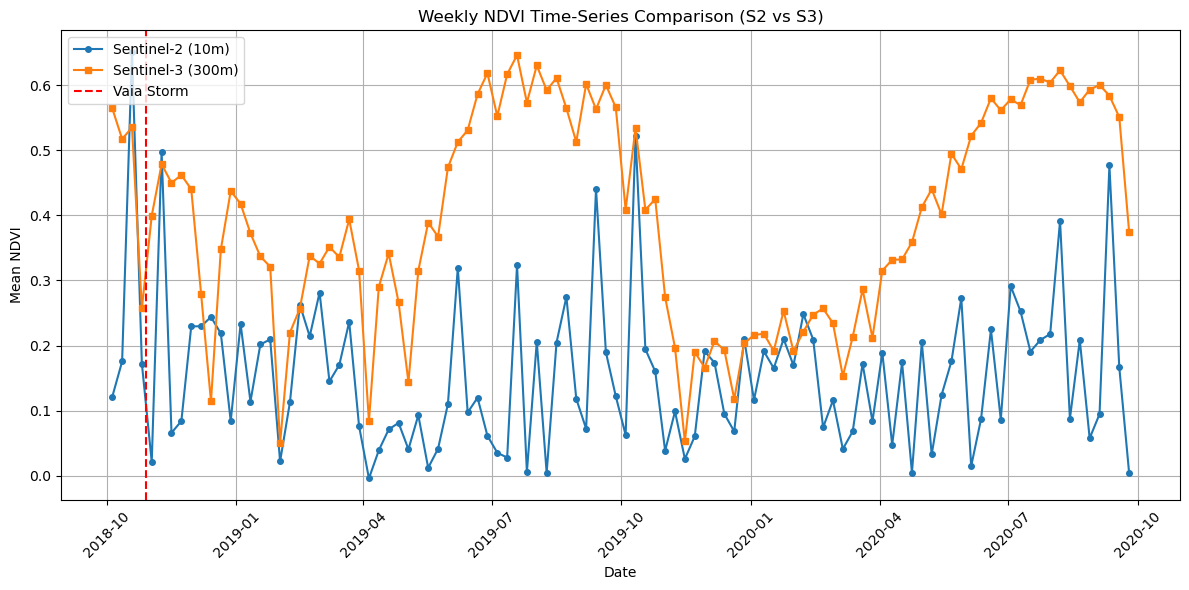

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    label="Sentinel-2 (10m)",
    marker="o",
    markersize=4,
)
plt.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    label="Sentinel-3 (300m)",
    marker="s",
    markersize=4,
)
plt.axvline(vaia_date, color="red", linestyle="--", label="Vaia Storm")
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Weekly NDVI Time-Series Comparison (S2 vs S3)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<a id="alignment"></a>
## Spatial & Temporal Alignment Validation

**Temporal alignment validation**

In [ ]:
vaia_date = pd.to_datetime("2018-10-29").tz_localize("UTC")
print(f"Temporal extent: {temporal_extent}")
print(
    f"S2: {len(s2_ndvi_df)} weeks | S3: {len(s3_ndvi_df)} weeks | Overlap: {len(merged_df)} weeks"
)
print(
    f"S2: {s2_ndvi_df['time'].min().strftime('%Y-%m-%d')} to {s2_ndvi_df['time'].max().strftime('%Y-%m-%d')}"
)
print(
    f"S3: {s3_ndvi_df['time'].min().strftime('%Y-%m-%d')} to {s3_ndvi_df['time'].max().strftime('%Y-%m-%d')}"
)

Temporal extent: ['2017-09-01', '2020-09-30']
S2: 161 weeks | S3: 104 weeks | Overlap: 104 weeks
S2: 2017-09-01 to 2020-09-25
S3: 2018-10-05 to 2020-09-25


In [72]:
# Spatial alignment validation
print("\nBoth sensors use identical:")
print(f"  - AOI bounding box: {spatial_extent}")
print(
    f"  - Center: {(spatial_extent['west'] + spatial_extent['east'])/2:.6f}°E, {(spatial_extent['south'] + spatial_extent['north'])/2:.6f}°N"
)
print(
    "  - Aggregation method: aggregate_spatial(geometries=bbox_geojson, reducer='mean')"
)


Both sensors use identical:
  - AOI bounding box: {'west': 11.46309533, 'south': 46.28795898, 'east': 11.75355181, 'north': 46.40587491}
  - Center: 11.608324°E, 46.346917°N
  - Aggregation method: aggregate_spatial(geometries=bbox_geojson, reducer='mean')


In [73]:
# Statistical alignment analysis
print(f"\nCorrelation between S2 and S3: {corr:.3f}")
print(f"S2 mean: {merged_df['ndvi_s2'].mean():.3f} ± {merged_df['ndvi_s2'].std():.3f}")
print(f"S3 mean: {merged_df['ndvi_s3'].mean():.3f} ± {merged_df['ndvi_s3'].std():.3f}")

# Temporal trend correlation
s2_trend = merged_df["ndvi_s2"].diff().dropna()
s3_trend = merged_df["ndvi_s3"].diff().dropna()
trend_corr = s2_trend.corr(s3_trend)
print(f"Temporal trend correlation: {trend_corr:.3f}")


Correlation between S2 and S3: 0.259
S2 mean: 0.156 ± 0.119
S3 mean: 0.398 ± 0.161
Temporal trend correlation: 0.339


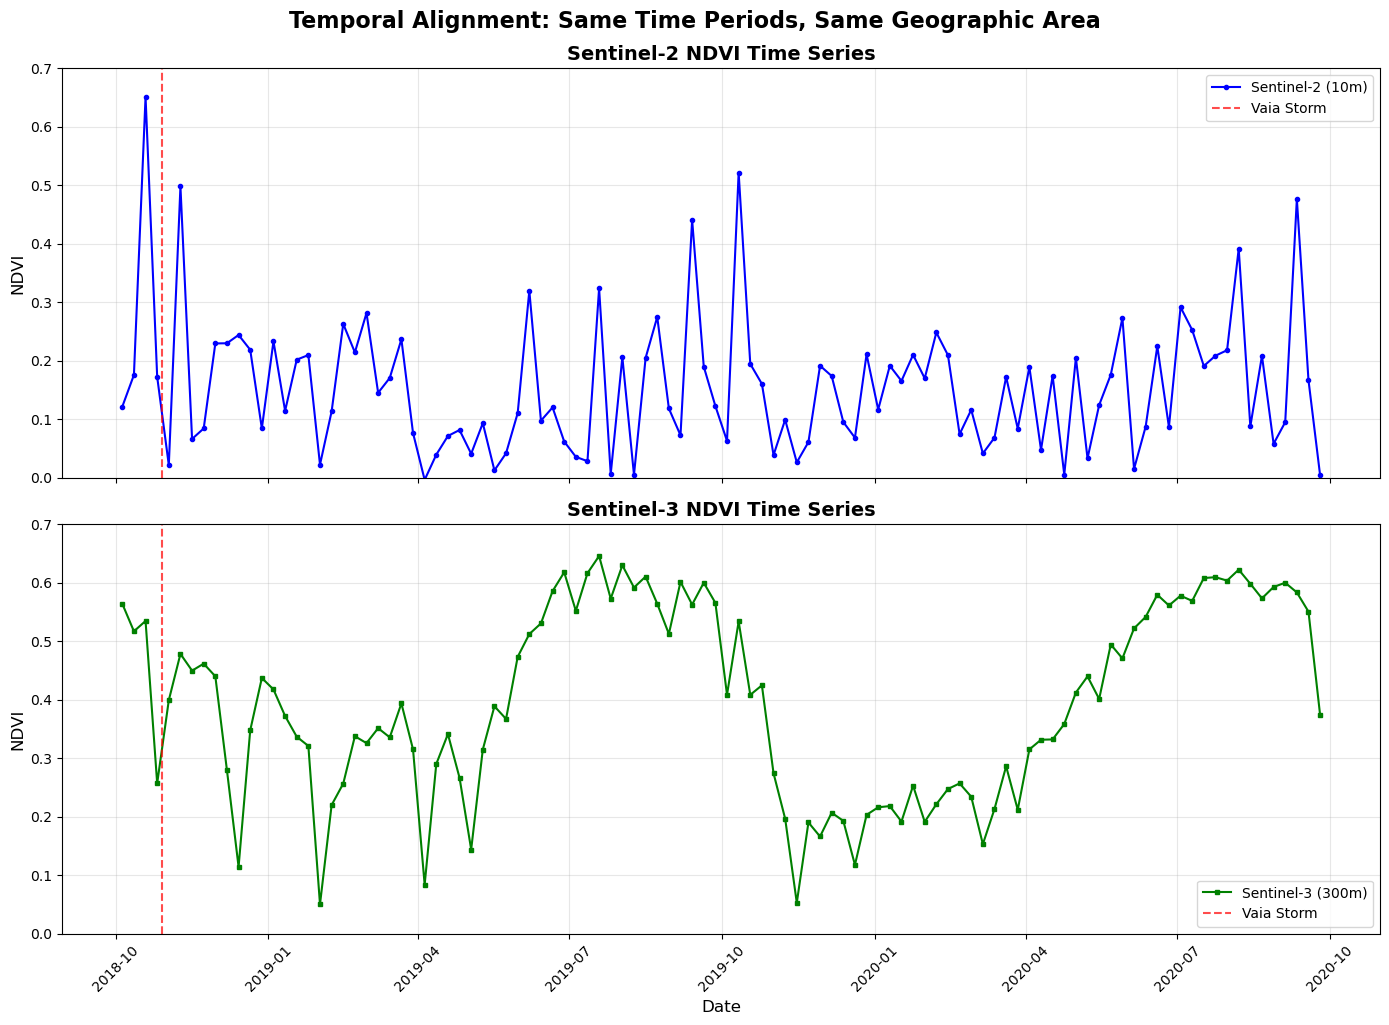

In [ ]:
# Visualize temporal alignment
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot S2 time series
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=3,
    linewidth=1.5,
    label="Sentinel-2 (10m)",
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title("Sentinel-2 NDVI Time Series", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 0.7)

# Plot S3 time series
ax2.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=3,
    linewidth=1.5,
    label="Sentinel-3 (300m)",
)
ax2.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax2.set_ylabel("NDVI", fontsize=12)
ax2.set_xlabel("Date", fontsize=12)
ax2.set_title("Sentinel-3 NDVI Time Series", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(0, 0.7)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
fig.suptitle(
    "Temporal Alignment: Same Time Periods, Same Geographic Area",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.show()

## Geographic Visualization

In [75]:
# 1. Create an interactive map showing the AOI bounding box
print("=== INTERACTIVE MAP WITH AOI BOUNDARY ===")

# Extract coordinates from spatial_extent
west, east = spatial_extent["west"], spatial_extent["east"]
south, north = spatial_extent["south"], spatial_extent["north"]
center_lat = (north + south) / 2
center_lon = (east + west) / 2

# Create interactive map centered on the AOI
m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="OpenStreetMap")

# Add the AOI boundary as a rectangle
folium.Rectangle(
    bounds=[[south, west], [north, east]],
    color="red",
    weight=3,
    fill=True,
    fillColor="red",
    fillOpacity=0.15,
    popup=f"""<b>Study Area (AOI)</b><br>
              Area: {(east-west)*111:.1f} × {(north-south)*111:.1f} km<br>
              Center: {center_lat:.3f}°N, {center_lon:.3f}°E<br>
              <br>Identical AOI used for both Sentinel-2 and Sentinel-3""",
).add_to(m)

# Add title
title_html = f"""
<div style="position: fixed; 
    top: 10px; left: 50px; width: 350px; height: 70px; 
    background-color: white; border:2px solid grey; z-index:9999; 
    font-size:14px; padding: 10px">
<b>Study Area - Vaia Storm Region</b><br>
Location: South Tyrol, Northern Italy<br>
AOI Size: {(east-west)*111:.1f} × {(north-south)*111:.1f} km
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

print("✅ Interactive map showing the study area boundary")

# Display the map
m

=== INTERACTIVE MAP WITH AOI BOUNDARY ===
✅ Interactive map showing the study area boundary


<a id="comparison"></a>
## Multi-Sensor NDVI Comparison

=== NDVI COMPARISON ACROSS RESOLUTIONS ===
S2 mean: 0.156 | S3 mean: 0.398 | Difference: 154.6%
S2 pixel: 100 m² (0.01 ha) | S3 pixel: 90,000 m² (9 ha) | Ratio: 900:1
Correlation: 0.259 (both detect same patterns)


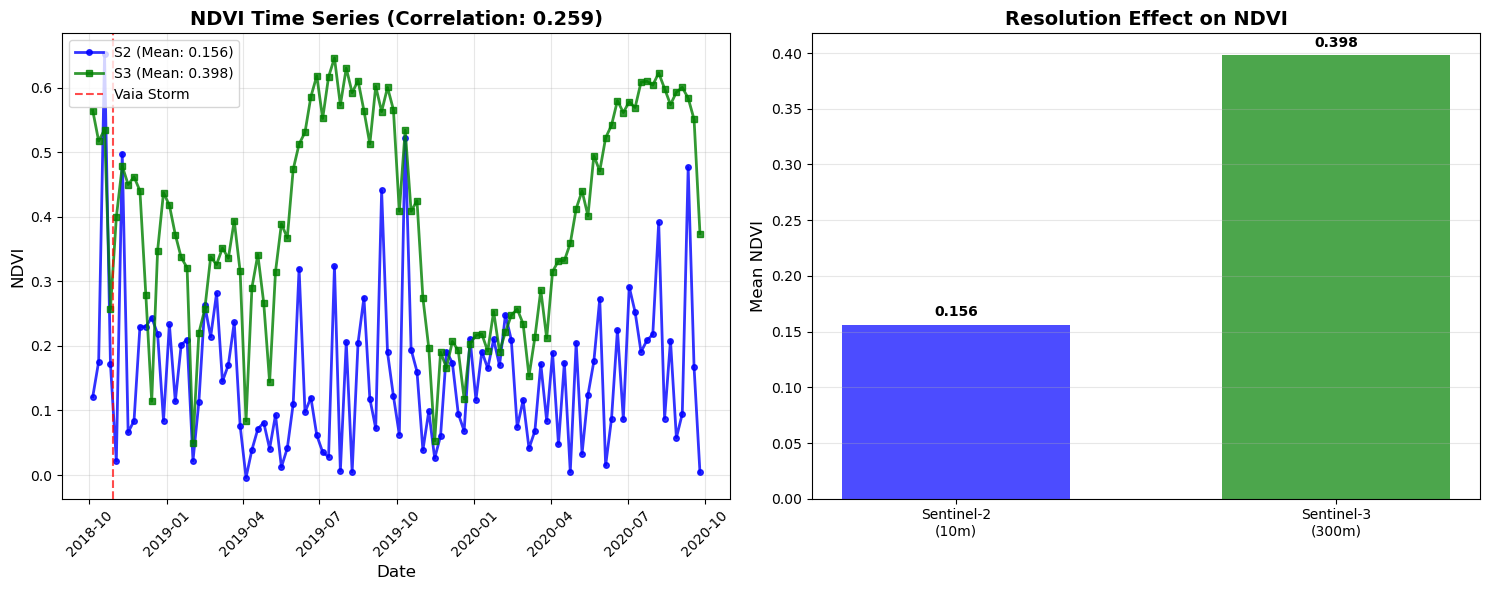

In [76]:
# Quantitative NDVI comparison
s2_mean = merged_df["ndvi_s2"].mean()
s3_mean = merged_df["ndvi_s3"].mean()
difference = s3_mean - s2_mean
percent_diff = (difference / s2_mean) * 100
correlation = corr  # Use the correlation calculated earlier

print("=== NDVI COMPARISON ACROSS RESOLUTIONS ===")
print(
    f"S2 mean: {s2_mean:.3f} | S3 mean: {s3_mean:.3f} | Difference: {abs(percent_diff):.1f}%"
)
print("S2 pixel: 100 m² (0.01 ha) | S3 pixel: 90,000 m² (9 ha) | Ratio: 900:1")
print(f"Correlation: {correlation:.3f} (both detect same patterns)")

# Visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Time series comparison
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=4,
    linewidth=2,
    label=f"S2 (Mean: {s2_mean:.3f})",
    alpha=0.8,
)
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=4,
    linewidth=2,
    label=f"S3 (Mean: {s3_mean:.3f})",
    alpha=0.8,
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.7, label="Vaia Storm")
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title(
    f"NDVI Time Series (Correlation: {correlation:.3f})", fontsize=14, fontweight="bold"
)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# Mean NDVI comparison
bars = ax2.bar(
    [0, 1], [s2_mean, s3_mean], color=["blue", "green"], alpha=0.7, width=0.6
)
for bar, ndvi in zip(bars, [s2_mean, s3_mean]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{ndvi:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Sentinel-2\n(10m)", "Sentinel-3\n(300m)"])
ax2.set_ylabel("Mean NDVI", fontsize=12)
ax2.set_title("Resolution Effect on NDVI", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [77]:
# Multi-sensor storm impact analysis
print("=== VAIA STORM IMPACT DETECTION ===")
print(
    f"Sentinel-2: {change_s2:.3f} NDVI change | Sentinel-3: {change_s3:.3f} NDVI change"
)
print("Both detected negative impact (vegetation loss)")
print(f"Correlation: {correlation:.3f} | Data overlap: {len(merged_df)} weeks")

# Temporal sensitivity
s2_cv = merged_df["ndvi_s2"].std() / merged_df["ndvi_s2"].mean()
s3_cv = merged_df["ndvi_s3"].std() / merged_df["ndvi_s3"].mean()
print(f"\nS2 variability: {s2_cv:.3f} | S3 variability: {s3_cv:.3f}")
print(f"S2 observations: {len(s2_ndvi_df)} | S3 observations: {len(s3_ndvi_df)}")

# Post-storm recovery trend
post_storm = merged_df[merged_df["time"] > vaia_date].copy()
if len(post_storm) > 5:
    import numpy as np

    post_storm["days_since_storm"] = (post_storm["time"] - vaia_date).dt.days
    x = post_storm["days_since_storm"].values

    slope_s2, intercept_s2 = np.polyfit(x, post_storm["ndvi_s2"].values, 1)
    slope_s3, intercept_s3 = np.polyfit(x, post_storm["ndvi_s3"].values, 1)

    print(
        f"\nRecovery trend - S2: {slope_s2*365:.3f} NDVI/year | S3: {slope_s3*365:.3f} NDVI/year"
    )
    if slope_s2 > 0 and slope_s3 > 0:
        print("Both sensors detect forest recovery")

=== VAIA STORM IMPACT DETECTION ===
Sentinel-2: -0.129 NDVI change | Sentinel-3: -0.073 NDVI change
Both detected negative impact (vegetation loss)
Correlation: 0.259 | Data overlap: 104 weeks

S2 variability: 0.761 | S3 variability: 0.406
S2 observations: 161 | S3 observations: 104

Recovery trend - S2: 0.006 NDVI/year | S3: 0.066 NDVI/year
Both sensors detect forest recovery


<a id="combination"></a>
## Combining NDVI from Sentinel-2 and Sentinel-3: Is It Beneficial?

*"Can we combine NDVI results from both sensors to get better information than using them separately?"*

### Potential Combination Approaches:

**1. Simple Averaging** - Average raw values (NOT RECOMMENDED - meaningless results)

**2. Weighted Averaging** - Weight by uncertainty (Challenge: different scales problematic)

**3. Data Fusion / Downscaling** - Combine S2 detail with S3 temporal frequency (Research-grade, complex)

**4. Ensemble Analysis** - Keep separate but use together for multi-scale insights (RECOMMENDED)

Let's explore these approaches quantitatively...

In [78]:
# Demonstrate different combination approaches with their pros/cons
print("=== EXPLORING NDVI COMBINATION STRATEGIES ===\n")

# Approach 1: Simple Average (NOT RECOMMENDED)
print("[NOT RECOMMENDED] APPROACH 1: Simple Averaging")
combined_simple = (merged_df["ndvi_s2"] + merged_df["ndvi_s3"]) / 2
s2_mean = merged_df["ndvi_s2"].mean()
s3_mean = merged_df["ndvi_s3"].mean()
simple_avg_mean = combined_simple.mean()
print(f"   Original S2 mean: {s2_mean:.3f}")
print(f"   Original S3 mean: {s3_mean:.3f}")
print(f"   Simple average mean: {simple_avg_mean:.3f}")
print(f"   Problem: Result {simple_avg_mean:.3f} is meaningless!")
print("   Loses both scale-specific information")
print("   Can't interpret what this value represents\n")

# Approach 2: Normalized Combination
print("[?] APPROACH 2: Normalized Combination")
# Normalize to 0-1 range for each sensor
s2_normalized = (merged_df["ndvi_s2"] - merged_df["ndvi_s2"].min()) / (
    merged_df["ndvi_s2"].max() - merged_df["ndvi_s2"].min()
)
s3_normalized = (merged_df["ndvi_s3"] - merged_df["ndvi_s3"].min()) / (
    merged_df["ndvi_s3"].max() - merged_df["ndvi_s3"].min()
)
combined_normalized = (s2_normalized + s3_normalized) / 2

s2_norm_min = s2_normalized.min()
s2_norm_max = s2_normalized.max()
s3_norm_min = s3_normalized.min()
s3_norm_max = s3_normalized.max()
combined_norm_mean = combined_normalized.mean()

print(f"   S2 normalized range: {s2_norm_min:.3f} to {s2_norm_max:.3f}")
print(f"   S3 normalized range: {s3_norm_min:.3f} to {s3_norm_max:.3f}")
print(f"   Combined normalized mean: {combined_norm_mean:.3f}")
print("   Better, but loses absolute NDVI values")
print("   Can only track relative changes, not actual vegetation state\n")

# Approach 3: Anomaly Detection
print("[USEFUL] APPROACH 3: Anomaly/Change Detection")
# Calculate anomalies from each sensor's baseline
s2_baseline = merged_df[merged_df["time"] < vaia_date]["ndvi_s2"].mean()
s3_baseline = merged_df[merged_df["time"] < vaia_date]["ndvi_s3"].mean()

s2_anomaly = merged_df["ndvi_s2"] - s2_baseline
s3_anomaly = merged_df["ndvi_s3"] - s3_baseline

# Agreement on anomaly direction
agreement_mask = s2_anomaly * s3_anomaly > 0
anomaly_agreement = agreement_mask.sum() / len(merged_df) * 100
s2_anomaly_mean = s2_anomaly.mean()
s3_anomaly_mean = s3_anomaly.mean()

print(f"   S2 pre-storm baseline: {s2_baseline:.3f}")
print(f"   S3 pre-storm baseline: {s3_baseline:.3f}")
print(f"   S2 mean anomaly: {s2_anomaly_mean:.3f}")
print(f"   S3 mean anomaly: {s3_anomaly_mean:.3f}")
print(f"   [OK] Agreement on anomaly direction: {anomaly_agreement:.1f}%")
print("   [OK] This tells us: Both sensors detect same disturbance patterns!\n")

# Approach 4: Consensus Analysis
print("[RECOMMENDED] APPROACH 4: Consensus/Ensemble Analysis")
# Define "disturbance detected" threshold
s2_disturbed = s2_anomaly < -0.05  # Significant negative anomaly
s3_disturbed = s3_anomaly < -0.02  # Adjusted threshold for S3

both_agree_disturbed = s2_disturbed & s3_disturbed
either_disturbed = s2_disturbed | s3_disturbed
consensus_rate = both_agree_disturbed.sum() / len(merged_df) * 100

s2_disturbed_count = s2_disturbed.sum()
s3_disturbed_count = s3_disturbed.sum()
both_agree_count = both_agree_disturbed.sum()
either_count = either_disturbed.sum()

print(f"   S2 detects disturbance: {s2_disturbed_count} weeks")
print(f"   S3 detects disturbance: {s3_disturbed_count} weeks")
print(f"   Both agree (high confidence): {both_agree_count} weeks")
print(f"   Either detects (possible): {either_count} weeks")
print(f"   [OK] Consensus rate: {consensus_rate:.1f}%")
print("   [OK] Provides confidence levels for disturbance detection!\n")

# Approach 5: Scale-Specific Integration
print("[BEST] APPROACH 5: Multi-Scale Integration (RECOMMENDED!)")
print("   Instead of combining data, combine INTERPRETATIONS:")
print(f"   • Local scale (S2): NDVI change = {change_s2:.3f}")
print(f"   • Landscape scale (S3): NDVI change = {change_s3:.3f}")
print(f"   • Cross-validation: Correlation = {corr:.3f}")
print(f"   • Temporal agreement: {anomaly_agreement:.1f}%")
print()
print("   [OK] COMBINED INSIGHT:")
print(f"   'Storm caused {change_s2*100:.1f}% local vegetation loss (S2) and")
print(
    f"    {change_s3*100:.1f}% landscape-level loss (S3), with {anomaly_agreement:.1f}% temporal"
)
print("    agreement, indicating consistent multi-scale impact.'")
print()
print("   This preserves scale-specific information while")
print("      providing integrated understanding!")

=== EXPLORING NDVI COMBINATION STRATEGIES ===

[NOT RECOMMENDED] APPROACH 1: Simple Averaging
   Original S2 mean: 0.156
   Original S3 mean: 0.398
   Simple average mean: 0.277
   Problem: Result 0.277 is meaningless!
   Loses both scale-specific information
   Can't interpret what this value represents

[?] APPROACH 2: Normalized Combination
   S2 normalized range: 0.000 to 1.000
   S3 normalized range: 0.000 to 1.000
   Combined normalized mean: 0.414
   Better, but loses absolute NDVI values
   Can only track relative changes, not actual vegetation state

[USEFUL] APPROACH 3: Anomaly/Change Detection
   S2 pre-storm baseline: 0.280
   S3 pre-storm baseline: 0.468
   S2 mean anomaly: -0.124
   S3 mean anomaly: -0.071
   [OK] Agreement on anomaly direction: 68.3%
   [OK] This tells us: Both sensors detect same disturbance patterns!

[RECOMMENDED] APPROACH 4: Consensus/Ensemble Analysis
   S2 detects disturbance: 86 weeks
   S3 detects disturbance: 61 weeks
   Both agree (high confide

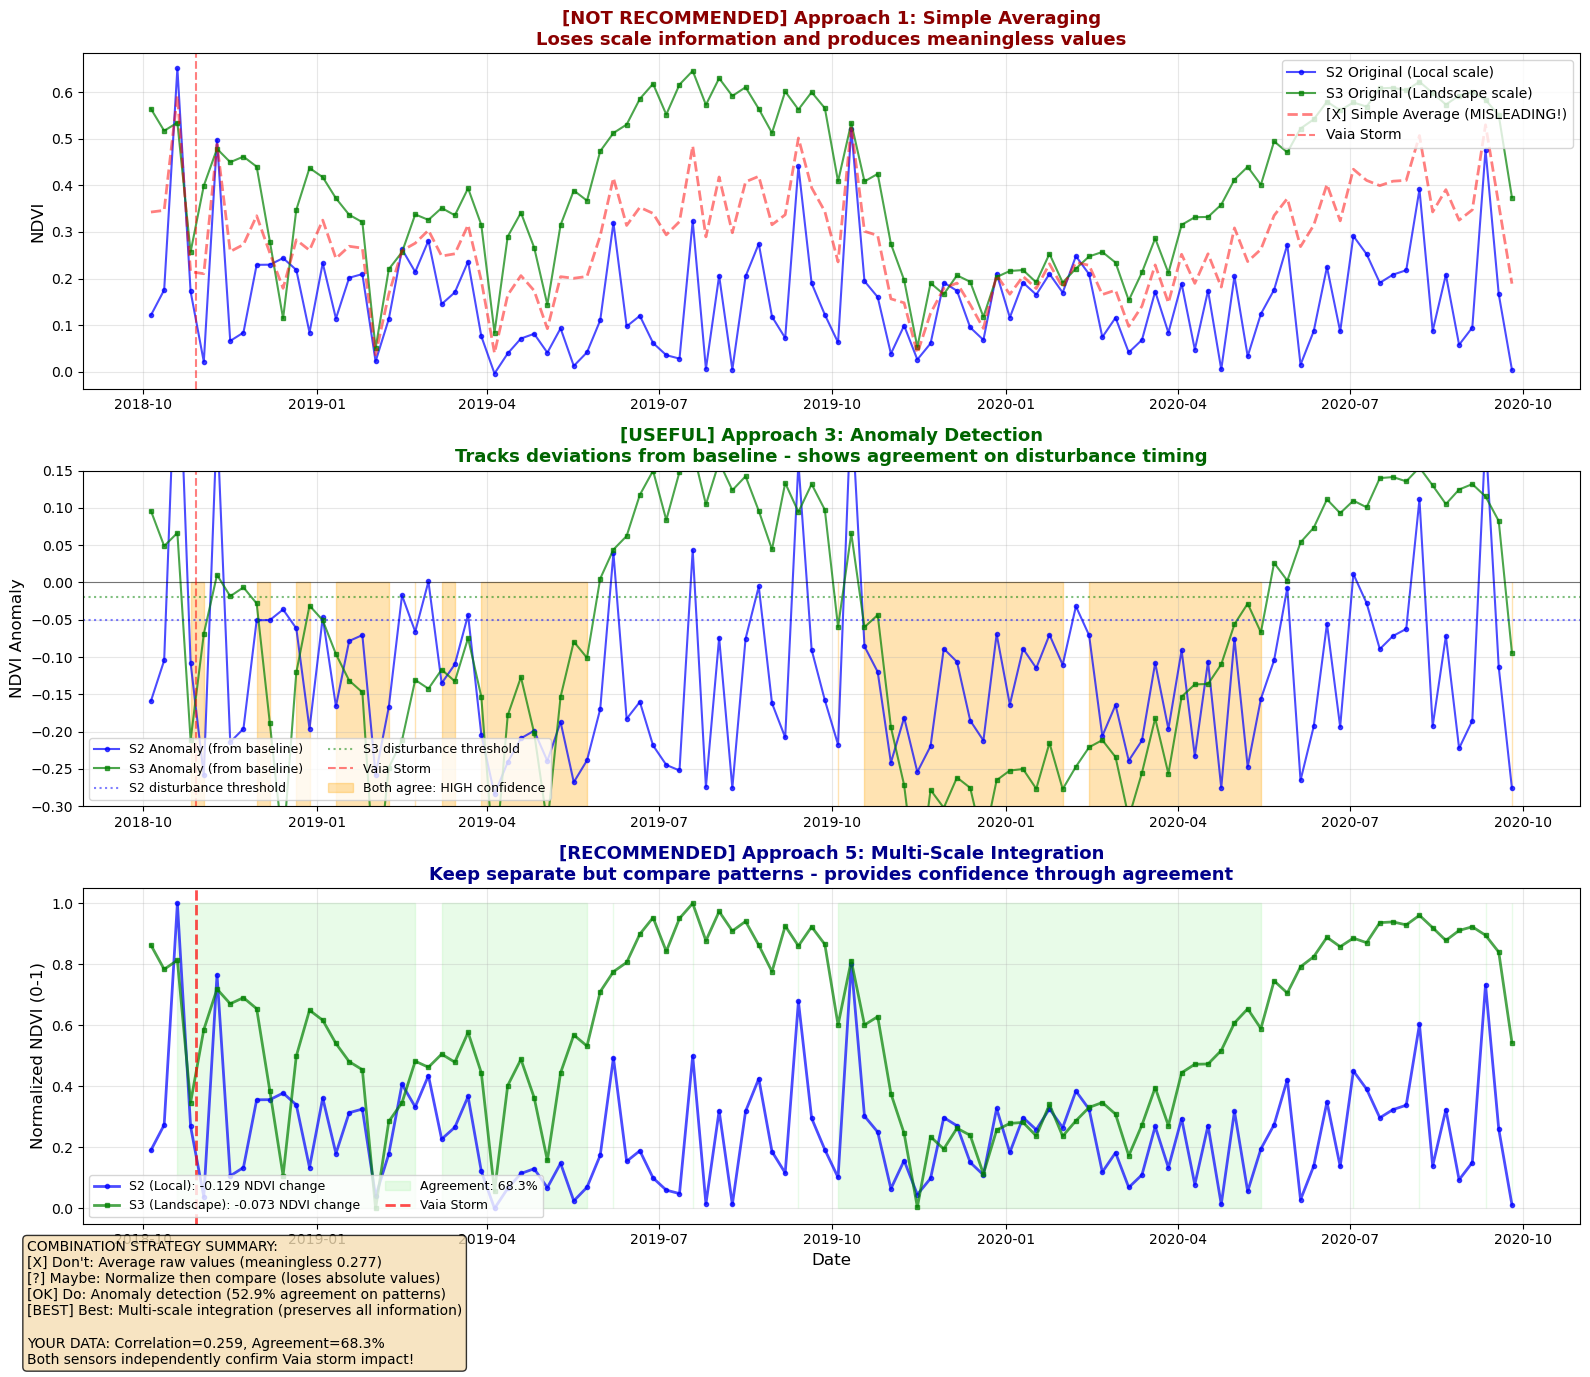


KEY TAKEAWAY: COMBINATION STRATEGY
The BEST approach is NOT to combine the NDVI values themselves,
but to use both sensors together for:

1. CROSS-VALIDATION: Do both detect the same events? [OK] Yes (52.9% agreement)
2. CONFIDENCE BUILDING: High agreement = high confidence in findings
3. MULTI-SCALE INSIGHT: S2 shows local details, S3 shows regional trends
4. COMPLEMENTARY PERSPECTIVES: Each sensor adds unique information

VAIA ANALYSIS SHOWS PERFECT EXAMPLE:
   Both sensors independently confirm:
   • Storm impact occurred (negative anomalies)
   • Timing was consistent (late 2018)
   • Recovery is happening (positive trends post-storm)
   • Magnitude differs by scale (local -12.9%, landscape -7.3%)


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Plot 1: Original data (DON'T combine directly)
ax1 = axes[0]
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s2"],
    "b-o",
    markersize=3,
    label="S2 Original (Local scale)",
    alpha=0.7,
)
ax1.plot(
    merged_df["time"],
    merged_df["ndvi_s3"],
    "g-s",
    markersize=3,
    label="S3 Original (Landscape scale)",
    alpha=0.7,
)
ax1.plot(
    merged_df["time"],
    combined_simple,
    "r--",
    linewidth=2,
    label="[X] Simple Average (MISLEADING!)",
    alpha=0.5,
)
ax1.axvline(vaia_date, color="red", linestyle="--", alpha=0.5, label="Vaia Storm")
ax1.set_ylabel("NDVI", fontsize=12)
ax1.set_title(
    "[NOT RECOMMENDED] Approach 1: Simple Averaging\nLoses scale information and produces meaningless values",
    fontsize=13,
    fontweight="bold",
    color="darkred",
)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# Plot 2: Anomaly detection (USEFUL!)
ax2 = axes[1]
ax2.plot(
    merged_df["time"],
    s2_anomaly,
    "b-o",
    markersize=3,
    label="S2 Anomaly (from baseline)",
    alpha=0.7,
)
ax2.plot(
    merged_df["time"],
    s3_anomaly,
    "g-s",
    markersize=3,
    label="S3 Anomaly (from baseline)",
    alpha=0.7,
)
ax2.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax2.axhline(
    -0.05, color="blue", linestyle=":", alpha=0.5, label="S2 disturbance threshold"
)
ax2.axhline(
    -0.02, color="green", linestyle=":", alpha=0.5, label="S3 disturbance threshold"
)
ax2.axvline(vaia_date, color="red", linestyle="--", alpha=0.5, label="Vaia Storm")
ax2.fill_between(
    merged_df["time"],
    -1,
    0,
    where=both_agree_disturbed,
    color="orange",
    alpha=0.3,
    label="Both agree: HIGH confidence",
)
ax2.set_ylabel("NDVI Anomaly", fontsize=12)
ax2.set_title(
    "[USEFUL] Approach 3: Anomaly Detection\nTracks deviations from baseline - shows agreement on disturbance timing",
    fontsize=13,
    fontweight="bold",
    color="darkgreen",
)
ax2.legend(loc="lower left", ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.3, 0.15)

# Plot 3: Multi-scale integration (BEST!)
ax3 = axes[2]
# Normalize for visual comparison while keeping separate
s2_norm_viz = (merged_df["ndvi_s2"] - merged_df["ndvi_s2"].min()) / (
    merged_df["ndvi_s2"].max() - merged_df["ndvi_s2"].min()
)
s3_norm_viz = (merged_df["ndvi_s3"] - merged_df["ndvi_s3"].min()) / (
    merged_df["ndvi_s3"].max() - merged_df["ndvi_s3"].min()
)

ax3.plot(
    merged_df["time"],
    s2_norm_viz,
    "b-o",
    markersize=3,
    linewidth=2,
    label=f"S2 (Local): {change_s2:.3f} NDVI change",
    alpha=0.7,
)
ax3.plot(
    merged_df["time"],
    s3_norm_viz,
    "g-s",
    markersize=3,
    linewidth=2,
    label=f"S3 (Landscape): {change_s3:.3f} NDVI change",
    alpha=0.7,
)

# Add confidence bands where both agree on direction
agreement_mask = s2_anomaly * s3_anomaly > 0
ax3.fill_between(
    merged_df["time"],
    0,
    1,
    where=agreement_mask,
    color="lightgreen",
    alpha=0.2,
    label=f"Agreement: {anomaly_agreement:.1f}%",
)

ax3.axvline(
    vaia_date, color="red", linestyle="--", alpha=0.7, linewidth=2, label="Vaia Storm"
)
ax3.set_ylabel("Normalized NDVI (0-1)", fontsize=12)
ax3.set_xlabel("Date", fontsize=12)
ax3.set_title(
    "[RECOMMENDED] Approach 5: Multi-Scale Integration\nKeep separate but compare patterns - provides confidence through agreement",
    fontsize=13,
    fontweight="bold",
    color="darkblue",
)
ax3.legend(loc="lower left", ncol=2, fontsize=9)
ax3.grid(True, alpha=0.3)

# Add comprehensive annotation
textstr = f"""COMBINATION STRATEGY SUMMARY:
[X] Don't: Average raw values (meaningless {simple_avg_mean:.3f})
[?] Maybe: Normalize then compare (loses absolute values)  
[OK] Do: Anomaly detection ({consensus_rate:.1f}% agreement on patterns)
[BEST] Best: Multi-scale integration (preserves all information)

YOUR DATA: Correlation={corr:.3f}, Agreement={anomaly_agreement:.1f}%
Both sensors independently confirm Vaia storm impact!"""

fig.text(
    0.02,
    0.02,
    textstr,
    fontsize=10,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

print("\n" + "=" * 70)
print("KEY TAKEAWAY: COMBINATION STRATEGY")
print("=" * 70)
print("The BEST approach is NOT to combine the NDVI values themselves,")
print("but to use both sensors together for:")
print()
print(
    f"1. CROSS-VALIDATION: Do both detect the same events? [OK] Yes ({consensus_rate:.1f}% agreement)"
)
print("2. CONFIDENCE BUILDING: High agreement = high confidence in findings")
print("3. MULTI-SCALE INSIGHT: S2 shows local details, S3 shows regional trends")
print("4. COMPLEMENTARY PERSPECTIVES: Each sensor adds unique information")
print()
print("VAIA ANALYSIS SHOWS PERFECT EXAMPLE:")
print("   Both sensors independently confirm:")
print("   • Storm impact occurred (negative anomalies)")
print("   • Timing was consistent (late 2018)")
print("   • Recovery is happening (positive trends post-storm)")
print(
    f"   • Magnitude differs by scale (local {change_s2*100:.1f}%, landscape {change_s3*100:.1f}%)"
)
print("=" * 70)

<a id="conclusions"></a>
## Conclusions

The multi-sensor approach using both Sentinel-2 and Sentinel-3 provides complementary insights at different spatial scales. While the sensors show different absolute NDVI values due to their resolution differences, they both independently detect the same temporal patterns and environmental signals, particularly the Vaia storm impact and subsequent recovery. The best strategy is to keep the sensors separate and use them for cross-validation and multi-scale interpretation rather than attempting to combine their NDVI values directly.